# **TaniMol: 06 - Cluster Visualization**

This notebook provides visual summaries of the clustering results computed in `04_clustering` and `05_activity_analysis`.  
Three complementary plots are generated *(for now)* for each fingerprint type (Morgan, MACCS, RDKit):

- **Similarity distribution** - global chemical diversity of the dataset  
- **Cluster size distribution** - how molecules are partitioned across clusters  
- **Top-N cluster heatmap** - internal structure of the largest chemical families

In [1]:
from src.config import PROCESSED_DIR
from src.visualization import (
    plot_similarity_distribution, plot_cluster_size_distribution,
    plot_top_clusters_heatmap, plot_cluster_activity_boxplots,
    plot_activity_cliff_scatter, plot_sali_distribution,
    plot_similarity_activity_density,
)
from src.activity_analysis import sali, similarity_activity_correlation
import pandas as pd
import numpy as np
import pickle


with open(f"{PROCESSED_DIR}/clustering_results.pkl", "rb") as f:
    results = pickle.load(f)

morgan_sim_matrix = results["morgan"]["similarity_matrix"]
morgan_clusters = results["morgan"]["clusters"]
morgan_singletons = results["morgan"]["singletons"]

maccs_sim_matrix = results["maccs"]["similarity_matrix"]
maccs_clusters = results["maccs"]["clusters"]
maccs_singletons = results["maccs"]["singletons"]

rdkit_sim_matrix = results["rdkit"]["similarity_matrix"]
rdkit_clusters = results["rdkit"]["clusters"]
rdkit_singletons = results["rdkit"]["singletons"]

df = pd.read_csv(f"{PROCESSED_DIR}/cleaned_activities.csv")
pic50 = df["pchembl_value"].values
delta_pic50 = np.abs(pic50[:, None] - pic50[None, :])

_, sali_values = sali(morgan_sim_matrix, delta_pic50)
rho, p_value = similarity_activity_correlation(morgan_sim_matrix, delta_pic50)

### **A. Pairwise Tanimoto Similarity Distribution**

Histogram of all pairwise Tanimoto similarities across the dataset (upper triangle only,
diagonal excluded). Each fingerprint type is overlaid on the same axis for direct comparison.

**How to read it:**  
- A distribution skewed towards 0 indicates a chemically diverse dataset with few redundant scaffolds - desirable for SAR analysis.  
- A peak near 1 would suggest many near-duplicate compounds.  
- Dashed vertical lines mark the mean similarity per fingerprint type.

**What to look for:**  
Morgan fingerprints typically show lower mean similarity than RDKit or MACCS,
because ECFP4 encodes local atomic environments at higher resolution.

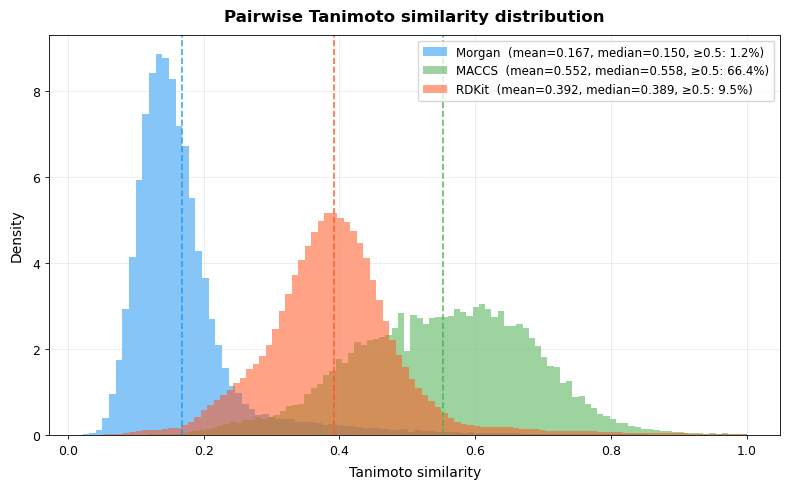

In [2]:
plot_similarity_distribution(
        matrices={
        "Morgan": morgan_sim_matrix, 
        "MACCS": maccs_sim_matrix, 
        "RDKit": rdkit_sim_matrix}
    )

### **B. Cluster Size Distribution**

Bar chart showing how many clusters fall into each size bin:
singleton (1 molecule), small (2–5), medium (6–20), large (21–50), and very large (>50).

**How to read it:**  
- A majority of singletons indicates the dataset contains many structurally unique compounds with no close analogs - common in diverse screening libraries.  
- Large clusters (>50) represent densely populated scaffold families, e.g. a PARP inhibitor series built around the same core.

**What to look for:**  
Differences between fingerprint types in this plot reveal how sensitive each fingerprint is
to structural variation - MACCS keys are coarser and will tend to produce larger clusters
than Morgan at the same Tanimoto threshold.

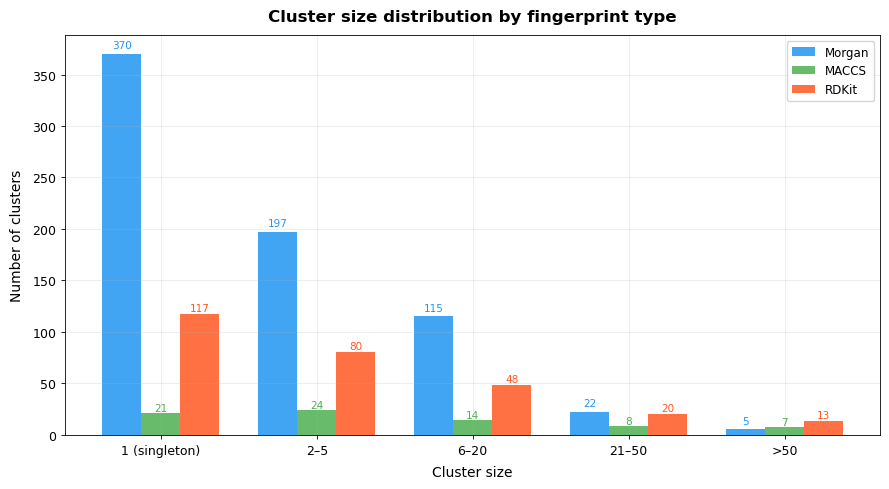

In [3]:
plot_cluster_size_distribution(
        clusters={"Morgan": morgan_clusters, "MACCS": maccs_clusters, "RDKit": rdkit_clusters},
        singletons={"Morgan": morgan_singletons, "MACCS": maccs_singletons, "RDKit": rdkit_singletons}
    )

### **C. Top-N Clusters Heatmap**

Tanimoto similarity heatmap restricted to the largest N clusters.
Molecules are ordered by cluster membership - each bright block on the diagonal
corresponds to one cluster. White lines mark cluster boundaries.

**How to read it:**  
- **Diagonal blocks** - bright (high similarity) by definition; their size reflects cluster size.  
- **Off-diagonal blocks** - dark means chemically distant clusters; bright means two clusters
  share similar scaffolds and could potentially be merged at a lower Tanimoto threshold.  
- Axis labels show cluster rank and size (e.g. `C1 (n=243)`).

**What to look for:**  
Bright off-diagonal blocks are scientifically interesting - they may indicate related
scaffold families that were split by the clustering threshold. These are candidates for
manual inspection or activity cliff analysis in `06_activity_analysis`.

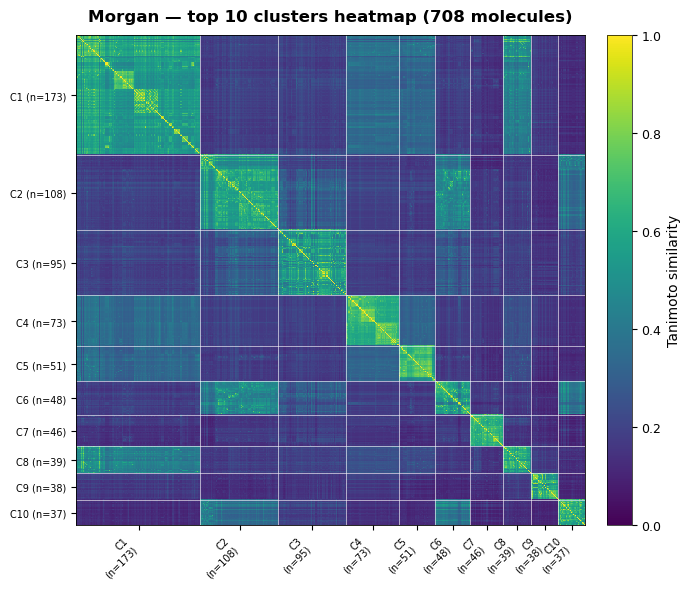

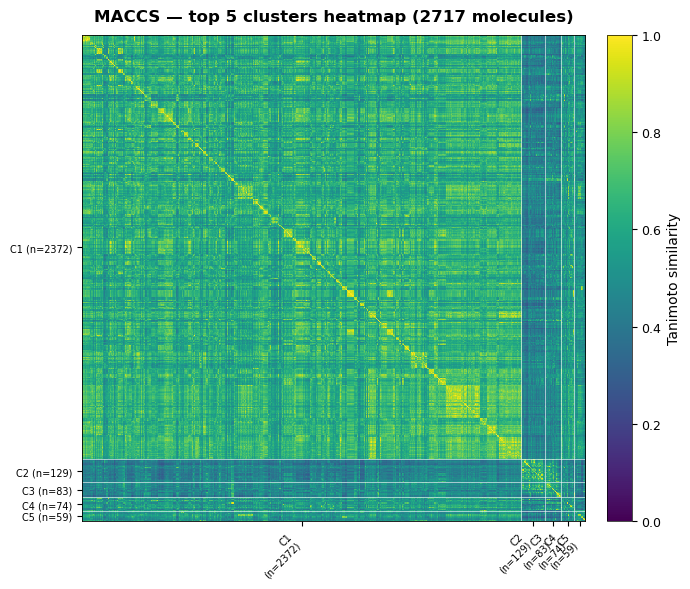

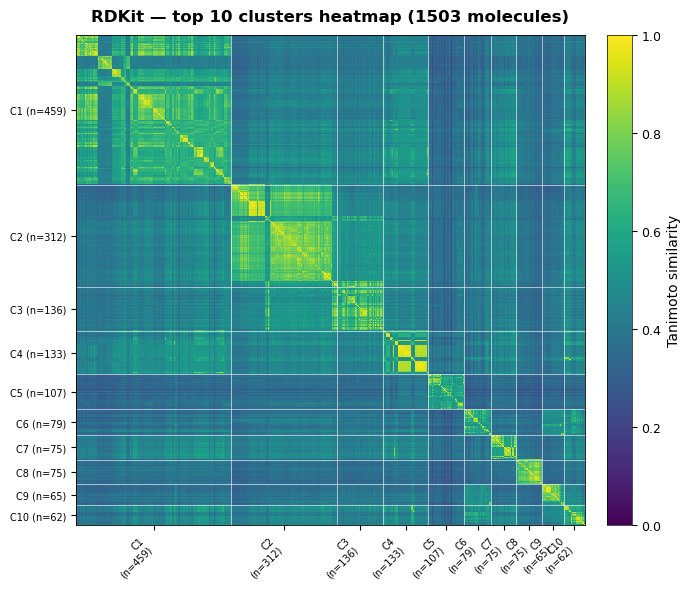

In [4]:
plot_top_clusters_heatmap(morgan_sim_matrix, morgan_clusters, name="Morgan", top_n=10)
plot_top_clusters_heatmap(maccs_sim_matrix, maccs_clusters, name="MACCS", top_n=5)
plot_top_clusters_heatmap(rdkit_sim_matrix, rdkit_clusters, name="RDKit", top_n=10)

### **D. Cluster Activity Boxplots**

pIC50 distribution within the largest Butina clusters (Morgan ECFP4). Each box represents one structural family - the median line shows typical potency, and the box width shows how consistent activity is within that scaffold.

**How to read it:**  
- A **tight box** (small IQR) means all molecules in that cluster have similar potency - SAR is working as expected.  
- A **wide box** or many outliers indicate activity cliffs - structurally similar molecules with very different potency.  
- Compare medians across clusters to identify the most potent scaffold families.

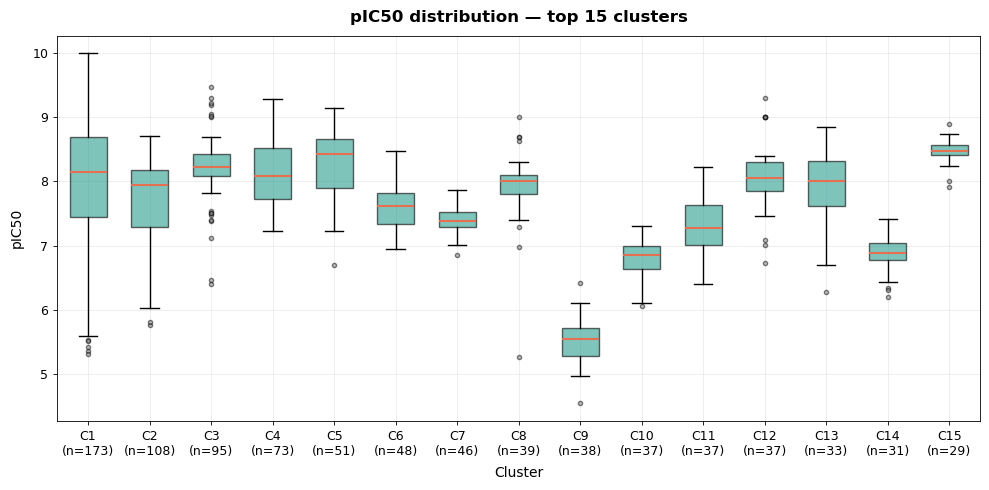

In [5]:
plot_cluster_activity_boxplots(morgan_clusters, pic50, top_n=15)

### **E. Activity Cliff Scatter**

Every unique molecular pair plotted as Tanimoto similarity (x-axis) vs |ΔpIC50| (y-axis). The pink-shaded zone in the top-right corner marks the activity cliff region (Tanimoto > 0.8 and |ΔpIC50| > 2.0).

**How to read it:**  
- **Grey cloud** - the bulk of all pairs, most of which are structurally dissimilar (low Tanimoto).  
- **Pink points** - activity cliffs: structurally similar molecules with dramatically different potency.  
- The dashed lines mark the detection thresholds.

**What to look for:**  
Points in the top-right corner are the most scientifically interesting - they represent specific structural modifications that cause >100-fold changes in potency.

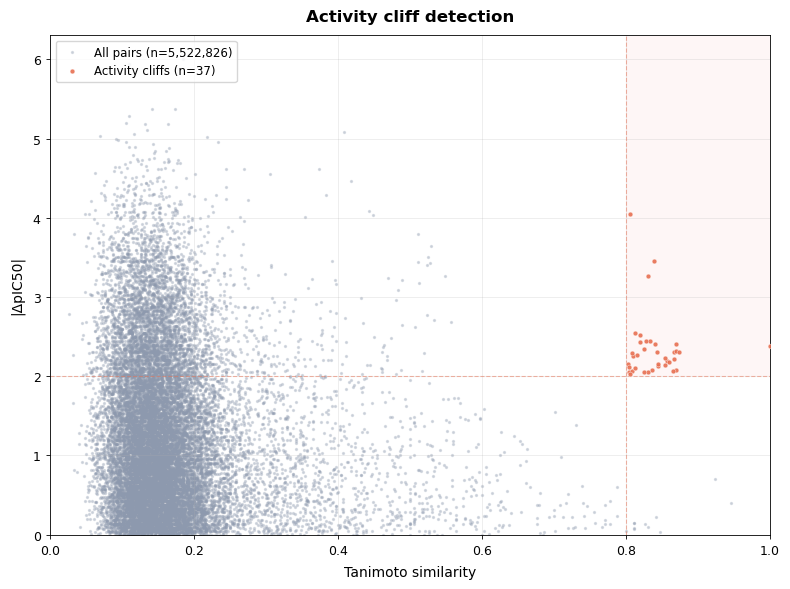

In [6]:
plot_activity_cliff_scatter(morgan_sim_matrix, delta_pic50)

### **F. SALI Distribution**

Histogram of the Structure-Activity Landscape Index for all non-zero molecular pairs. SALI = |ΔpIC50| / (1 − Tanimoto), amplifying cases where very similar molecules have very different activities.

**How to read it:**  
- The bulk of pairs cluster near zero - most pairs either differ structurally or have similar activity.  
- The **95th and 99th percentile** lines mark the boundary of extreme activity cliffs.  
- Any pair beyond the 99th percentile represents a dramatic, pharmacologically relevant structure-activity discontinuity.

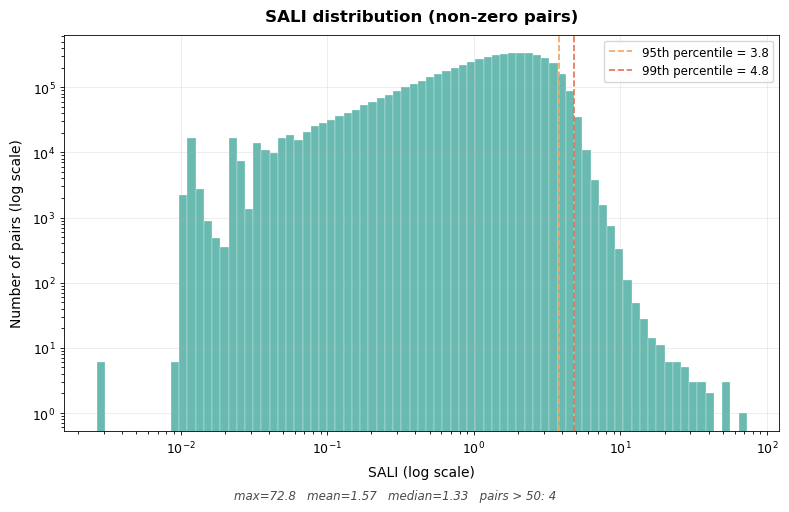

In [7]:
plot_sali_distribution(sali_values)

### **G. Similarity–Activity Landscape (Density)**

Hexbin density plot visualizing the global relationship between structural similarity and activity difference. Color intensity represents the number of molecular pairs in each region. The Spearman ρ annotation quantifies the overall SAR trend.

**How to read it:**  
- A **hot zone** at low Tanimoto / low |ΔpIC50| confirms most dissimilar molecules also differ moderately in activity.  
- A **negative Spearman ρ** confirms that similar molecules tend to have similar activity (SAR holds).  
- Scattered points at high Tanimoto / high |ΔpIC50| are the activity cliffs visible in plots E and F.

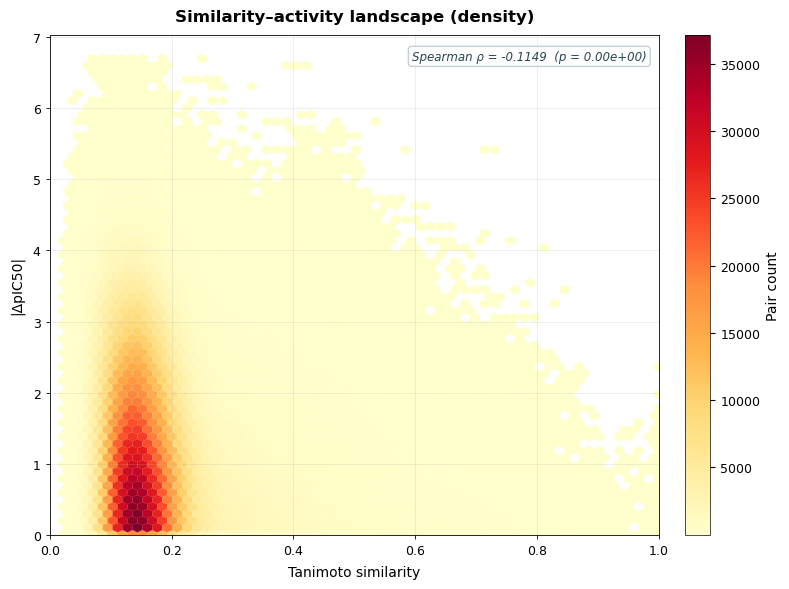

In [8]:
plot_similarity_activity_density(morgan_sim_matrix, delta_pic50, rho=rho, p_value=p_value)